# Krylov Quantum Diagonalization (KQD): simple local version



## Setup

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.primitives import StatevectorEstimator

## Step 1: Map the problem to a quantum problem

**Hamiltonian:** Heisenberg chain $H=\sum_i X_iX_{i+1}+Y_iY_{i+1}+J\,Z_iZ_{i+1}$ .

**Reference state:** one excitation, $|\psi\rangle = X_{q}|0\ldots0\rangle$. Since $H$ conserves the number of $|1\rangle$s, everything stays in the $n$-dimensional *single-particle sector*. We diagonalize that small block exactly to get the **answer key** `gs_en` .

**Time step:** $dt=\pi/\|H\|$. **Krylov space:** $\{|\psi\rangle,\,e^{-iH\,dt}|\psi\rangle,\dots\}$.

In [2]:
n_qubits = 10          # chain length (the tutorial uses 30)
J = 1                  # ZZ coupling

# Hamiltonian as a sum of Pauli strings (open chain, nearest neighbours)
terms = []
for i in range(n_qubits - 1):
    terms += [("XX", [i, i + 1], 1.0), ("YY", [i, i + 1], 1.0), ("ZZ", [i, i + 1], J)]
H_op = SparsePauliOp.from_sparse_list(terms, num_qubits=n_qubits)
print("number of Pauli terms:", len(H_op))

# Exact answer key: H restricted to the single-particle sector
H_sparse = H_op.to_matrix(sparse=True).tocsr()
sector = [1 << q for q in range(n_qubits)]                 # basis states with exactly one |1>
single_particle_H = H_sparse[sector][:, sector].toarray().real
gs_en = np.linalg.eigvalsh(single_particle_H)[0]
print("exact single-particle ground state energy:", gs_en)

# Algorithm parameters
dt = np.pi / np.linalg.norm(single_particle_H, ord=2)      # tutorial: dt = pi / ||H||
krylov_dim = 6                                             # size of the Krylov subspace
num_trotter_steps = 20                                     # Trotter steps per time evolution
dt_circ = dt / num_trotter_steps                           # time per Trotter step
excitation = n_qubits // 2                                 # qubit that carries the excitation
E_vac = J * (n_qubits - 1)                                 # energy of |00...0>
print("dt =", dt)

number of Pauli terms: 27
exact single-particle ground state energy: 1.195773934819385
dt = 0.3490658503988659


## Step 2: Build the (optimized) circuits

**Time evolution:** first-order Trotter product formula. Each step applies $e^{-i\tau(XX+YY+JZZ)}$ on every bond, even bonds first, then odd bonds (alternating the order on successive steps). Qiskit's `rxx(θ)` means $e^{-i\theta XX/2}$, so we pass `θ = 2τ`.


Circuit: `H(anc)` → controlled prep → $U$ (uncontrolled) → `X(anc)` → controlled prep → `X(anc)`.

In [3]:
def trotter_evolution(n, J, theta, reps, offset=0):
    # Brickwork Trotter circuit. theta = 2 * (time per Trotter step).
    qc = QuantumCircuit(n + offset)
    even = [(i, i + 1) for i in range(0, n - 1, 2)]
    odd  = [(i, i + 1) for i in range(1, n - 1, 2)]
    for s in range(reps):
        layers = [even, odd] if s % 2 == 0 else [odd, even]
        for layer in layers:
            for a, b in layer:
                qc.rxx(theta,     a + offset, b + offset)
                qc.ryy(theta,     a + offset, b + offset)
                qc.rzz(J * theta, a + offset, b + offset)
    return qc

t = Parameter("t")          # rotation angle; we sweep it to get different k

qc = QuantumCircuit(n_qubits + 1)                 # qubit 0 = ancilla, qubits 1..n = system
qc.h(0)
qc.cx(0, excitation + 1)                          # controlled preparation of |psi>
qc.compose(trotter_evolution(n_qubits, J, t, num_trotter_steps, offset=1), inplace=True)
qc.x(0)
qc.cx(0, excitation + 1)                          # 0-controlled preparation
qc.x(0)

print("circuit qubits:", qc.num_qubits, "| depth:", qc.depth())
print("gate counts:", dict(qc.count_ops()))

circuit qubits: 11 | depth: 124
gate counts: {'rxx': 180, 'ryy': 180, 'rzz': 180, 'cx': 2, 'x': 2, 'h': 1}


## Step 3: Execute with the Estimator primitive

Because of time-translation invariance ($\langle\psi_j|H|\psi_k\rangle=\langle\psi|H\,U^{k-j}|\psi\rangle$), we only need the **first row** of $\tilde S$ and $\tilde H$: $\langle\psi|P\,U^k|\psi\rangle$ for each Pauli term $P$ and $k=0,\dots,r-1$.

For a Pauli string $P$ on the system, measuring the ancilla in $X$ or $Y$ jointly with $P$ gives the real and imaginary parts:
$\langle X\otimes P\rangle=\mathrm{Re}[e^{-i\phi}\langle\psi|PU|\psi\rangle]$, $\langle Y\otimes P\rangle=\mathrm{Im}[\cdot]$.

`P.tensor(Pauli("X"))` puts the `X` on qubit 0 (the ancilla) and $P$ on the system qubits. One call sweeps all $k$ at once: observables of shape `(n_obs, 1)` against angles of shape `(krylov_dim,)`. 

In [4]:
# Observables: ancilla-only X, Y (for S) and X⊗P, Y⊗P for every Pauli term P of H
obs_S  = [SparsePauliOp("I" * n_qubits + "X"), SparsePauliOp("I" * n_qubits + "Y")]
obs_HX = [SparsePauliOp(P.tensor(Pauli("X"))) for P in H_op.paulis]
obs_HY = [SparsePauliOp(P.tensor(Pauli("Y"))) for P in H_op.paulis]
observables = [[o] for o in obs_S + obs_HX + obs_HY]         # shape (n_obs, 1)

ks = np.arange(krylov_dim)                                   # k = 0, 1, ..., r-1
params = 2 * dt_circ * ks                                    # rotation angle for each k

estimator = StatevectorEstimator()                           # exact local Estimator
result = estimator.run([(qc, observables, params)]).result()[0]
evs = result.data.evs                                        # shape (n_obs, krylov_dim)
print("expectation-value grid:", evs.shape)

expectation-value grid: (56, 6)


## Step 4: Post-process

1. Undo the vacuum phase: $\langle\psi|PU^k|\psi\rangle = e^{-iE_{vac}k\,dt}\,(\langle X\otimes P\rangle+i\langle Y\otimes P\rangle)$.
2. First row of $\tilde S$: the $P=I$ values. First row of $\tilde H$: $\sum_P c_P\langle\psi|PU^k|\psi\rangle$.
3. Fill the full Hermitian Toeplitz matrices (lower triangle = complex conjugate of the upper).
4. Solve the generalized eigenvalue problem $\tilde H\vec c=E\tilde S\vec c$ after discarding directions where $\tilde S$ is nearly singular (`threshold`). 

In [5]:
n_terms = len(H_op)
coeffs = H_op.coeffs.real
prefactors = np.exp(-1j * E_vac * ks * dt)                   # vacuum phase correction

S_first_row = prefactors * (evs[0] + 1j * evs[1])
H_first_row = prefactors * (coeffs[:, None] * (evs[2:2 + n_terms] + 1j * evs[2 + n_terms:])).sum(axis=0)

print("S[0,0] (should be 1):", np.round(S_first_row[0], 10))
print("H[0,0] (should be <psi|H|psi> =", single_particle_H[excitation, excitation], "):", np.round(H_first_row[0], 10))

def toeplitz_from_first_row(row):
    r = len(row)
    M = np.zeros((r, r), dtype=complex)
    for j in range(r):
        for i in range(r):
            M[j, i] = row[i - j] if i >= j else np.conj(row[j - i])
    return M

S_circ = toeplitz_from_first_row(S_first_row)
H_eff_circ = toeplitz_from_first_row(H_first_row)

S[0,0] (should be 1): (1+0j)
H[0,0] (should be <psi|H|psi> = 5.0 ): (5+0j)


In [6]:
def solve_regularized_gen_eig(h, s, threshold):
    # Lowest eigenvalue of h c = E s c, after dropping directions where s is (nearly) singular.
    s_vals, s_vecs = scipy.linalg.eigh(s)
    keep = s_vals > threshold
    W = s_vecs[:, keep]
    h_reg = W.conj().T @ h @ W
    s_reg = W.conj().T @ s @ W
    return scipy.linalg.eigh(h_reg, s_reg, eigvals_only=True)[0]

gnd_en_circ_est_list = []
for d in range(1, krylov_dim + 1):
    est = solve_regularized_gen_eig(H_eff_circ[:d, :d], S_circ[:d, :d], threshold=1e-8)
    gnd_en_circ_est_list.append(est)
    print(f"Krylov dimension {d}: estimated ground state energy = {est:.6f}")

print("exact single-particle ground state energy        =", round(gs_en, 6))

Krylov dimension 1: estimated ground state energy = 5.000000
Krylov dimension 2: estimated ground state energy = 2.367430
Krylov dimension 3: estimated ground state energy = 1.653401
Krylov dimension 4: estimated ground state energy = 1.374415
Krylov dimension 5: estimated ground state energy = 1.253583
Krylov dimension 6: estimated ground state energy = 1.217838
exact single-particle ground state energy        = 1.195774


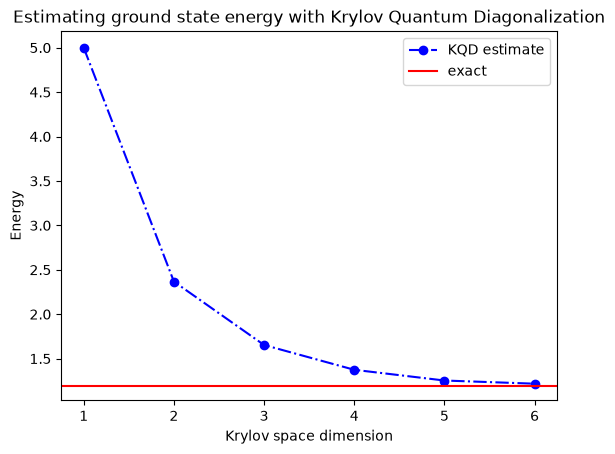

In [7]:
plt.plot(range(1, krylov_dim + 1), gnd_en_circ_est_list, "o-.", color="blue", label="KQD estimate")
plt.axhline(gs_en, color="red", label="exact")
plt.xticks(range(1, krylov_dim + 1))
plt.xlabel("Krylov space dimension")
plt.ylabel("Energy")
plt.title("Estimating ground state energy with Krylov Quantum Diagonalization")
plt.legend()
plt.show()

## Optional sanity check: same KQD without any circuits

If the numbers above ever look wrong, this isolates whether the problem is in the circuits or in the linear algebra. It uses exact matrix exponentials in the single-particle sector. Expect estimates close to the ones above (small differences come from Trotter error and the Toeplitz shortcut), all decreasing and staying above the exact value.

In [8]:
U = scipy.linalg.expm(-1j * single_particle_H * dt)
psi = np.zeros(n_qubits, dtype=complex); psi[excitation] = 1
vecs = [psi]
for _ in range(krylov_dim - 1):
    vecs.append(U @ vecs[-1])
V = np.array(vecs).T
S_ref = V.conj().T @ V
H_ref = V.conj().T @ single_particle_H @ V

for d in range(1, krylov_dim + 1):
    e = solve_regularized_gen_eig(H_ref[:d, :d], S_ref[:d, :d], threshold=1e-8)
    print(f"Krylov dimension {d}: exact-evolution estimate = {e:.6f}   circuit estimate = {gnd_en_circ_est_list[d-1]:.6f}")

Krylov dimension 1: exact-evolution estimate = 5.000000   circuit estimate = 5.000000
Krylov dimension 2: exact-evolution estimate = 2.367413   circuit estimate = 2.367430
Krylov dimension 3: exact-evolution estimate = 1.650870   circuit estimate = 1.653401
Krylov dimension 4: exact-evolution estimate = 1.366064   circuit estimate = 1.374415
Krylov dimension 5: exact-evolution estimate = 1.247279   circuit estimate = 1.253583
Krylov dimension 6: exact-evolution estimate = 1.211431   circuit estimate = 1.217838
